   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Sh

/tmp/ipykernel_16742/4119569052.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
/tmp/ipykernel_16742/4119569052.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

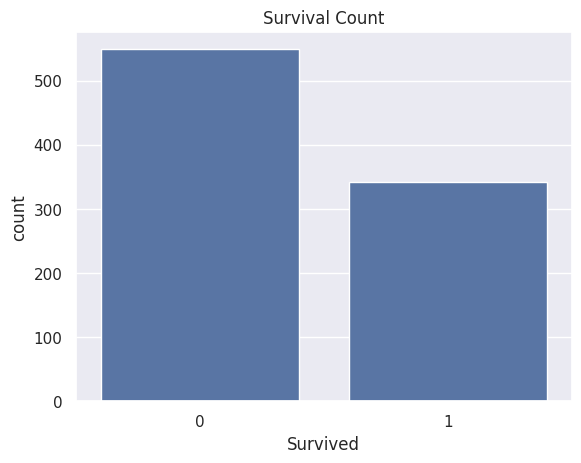

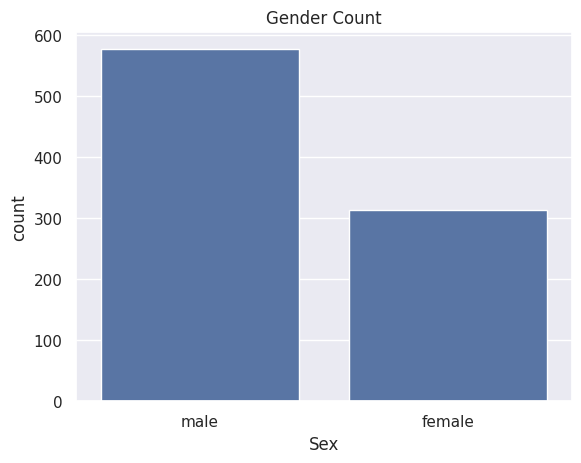

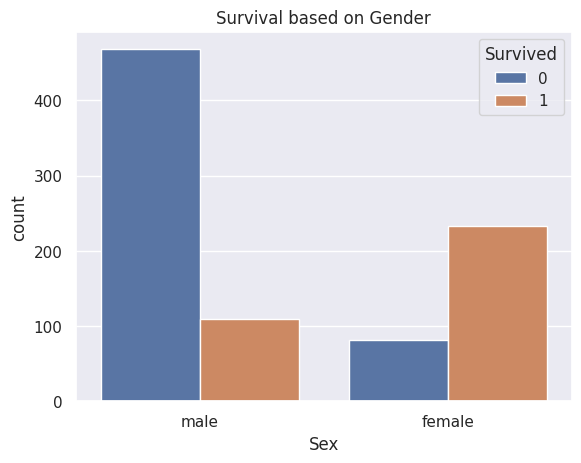

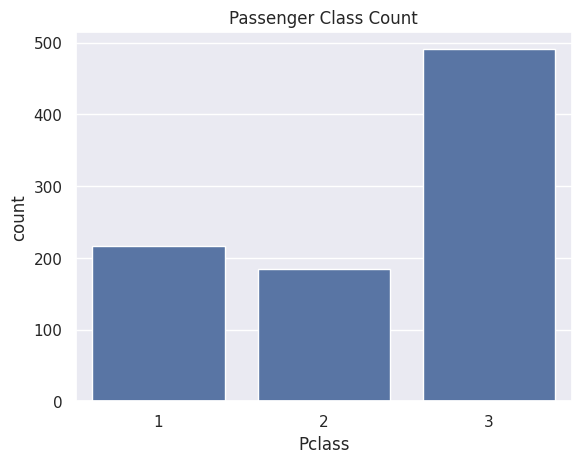

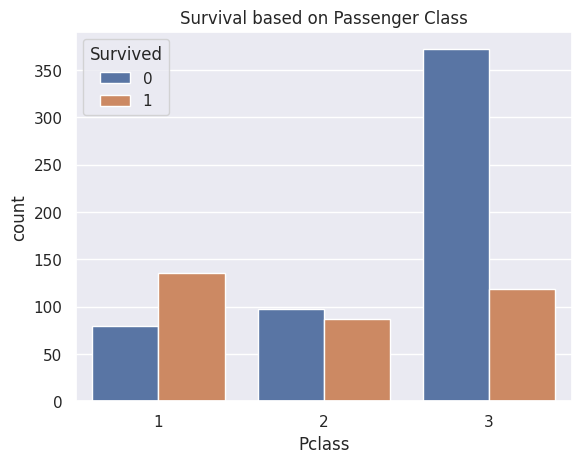


Sex Value Counts:

Sex
male      577
female    314
Name: count, dtype: int64

Embarked Value Counts:

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Dataset after Encoding:

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare  Embarked  
0         A/5 21171   7.2500         0  
1          PC 17599  71

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load Dataset
data = pd.read_csv("Titanic_survival.csv")

# Display first 5 rows
print(data.head())

# Shape of dataset
print("Shape of dataset:", data.shape)

# Dataset information
print(data.info())

# Check missing values
print("\nMissing Values:\n")
print(data.isnull().sum())

# Drop Cabin column because too many missing values
data = data.drop(columns='Cabin', axis=1)

# Fill missing values
data['Age'] = data['Age'].fillna(data['Age'].mean())
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
data['Fare'].fillna(data['Fare'].mode()[0], inplace=True)

# Confirm no missing values
print("\nTotal Missing Values After Cleaning:", data.isnull().sum().sum())

# Statistical summary
print("\nDataset Description:\n")
print(data.describe())

# Count plot for Survived
sns.set()
sns.countplot(x='Survived', data=data)
plt.title("Survival Count")
plt.show()

# Count plot for Gender
sns.countplot(x='Sex', data=data)
plt.title("Gender Count")
plt.show()

# Survival based on Gender
sns.countplot(x='Sex', hue='Survived', data=data)
plt.title("Survival based on Gender")
plt.show()

# Count plot for Passenger Class
sns.countplot(x='Pclass', data=data)
plt.title("Passenger Class Count")
plt.show()

# Survival based on Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=data)
plt.title("Survival based on Passenger Class")
plt.show()

# Check unique values
print("\nSex Value Counts:\n")
print(data['Sex'].value_counts())

print("\nEmbarked Value Counts:\n")
print(data['Embarked'].value_counts())

# Convert categorical columns to numerical
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data['Embarked'] = data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Display updated dataset
print("\nDataset after Encoding:\n")
print(data.head())

# Separate Features and Target
X = data.drop(columns=['PassengerId', 'Name', 'Ticket', 'Survived'], axis=1)
Y = data['Survived']

print("\nFeatures (X):\n")
print(X.head())

print("\nTarget (Y):\n")
print(Y.head())

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

print("\nShapes:")
print(X.shape, X_train.shape, X_test.shape)

# Model Training
model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

# Prediction on Training Data
X_train_prediction = model.predict(X_train)

# Training Accuracy
train_data_accuracy = accuracy_score(Y_train, X_train_prediction)
print("\nAccuracy Score of Training Data:", train_data_accuracy)

# Prediction on Test Data
X_test_prediction = model.predict(X_test)

# Testing Accuracy
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)
print("Accuracy Score of Testing Data:", test_data_accuracy)